In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging

from preprocessor import Preprocessor
from visualizer import Visualizer
from semantic import SemanticAnalyser
from agent import Agent, PRICE_MAPPER
from config_local import config
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

logger = logging.getLogger(__name__)

/Users/richardzhang/project-milestone-p2-group11/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [85]:
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)
semantic_analyser = SemanticAnalyser(config=config)
df = preprocessor.get_merged_input_files()
resolved_df = preprocessor.resolve_all_parsed_paths(df.copy())

In [4]:
# parsing links.tsv into pd.DataFrame
links_df = preprocessor.parse_input_file('data/wikispeedia_paths-and-graph/links.tsv')

# create link mapping from links_df
link_mappings = preprocessor.get_link_mappings(links_df)

# create high level agent instance
agent = Agent(config, link_mappings)

# llm_tot_path = agent.navigate_tot(start, destination, with_memory=False)
# f'Path generated by LLM using ToT: {llm_tot_path}'

In [5]:
llm_path_20b = pd.read_csv('results/llm_paths_merged_oss_20b.csv')
llm_path_120b = pd.read_csv('results/llm_paths_oss_120b.csv')

In [9]:
llm_path_120b['difficulty'] = llm_path_20b['difficulty']

In [13]:
# merging two dataframes on common columns, and add a cloumn to indicate source
llm_path_merged = pd.concat([llm_path_20b.assign(model='oss_20b'), llm_path_120b.assign(model='oss_120b')], ignore_index=True)

In [31]:
# python
import ast


def _last_item_from_path_cell(cell) -> str | None:
    if pd.isna(cell):
        return None
   
    if isinstance(cell, (list, tuple)):
        return str(cell[-1]).strip() if len(cell) > 0 else None
    s = str(cell).strip()
    
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple)) and len(parsed) > 0:
            return str(parsed[-1]).strip()
    except Exception:
        pass
    # 常见分隔符分割
    for sep in ['->', '|', ',', ';', '/']:
        if sep in s:
            return s.split(sep)[-1].strip()
   
    return s if s != '' else None

def is_valid_path(path,destination):
    last_item = _last_item_from_path_cell(path)
    if last_item is None:
        return False
    return last_item == destination

In [30]:
#compute success rate by both model, difficulty and method, and success rate is defined by if last page in path is destination
llm_path_stats = llm_path_merged.copy()
_last_item_from_path_cell(llm_path_stats['link_aware_paths'][0])

'Internet'

In [32]:
# compute success rate for all combinations of model, difficulty and method
llm_path_stats['link_aware_success'] = llm_path_stats.apply(lambda row: is_valid_path(row['link_aware_paths'], row['destination']), axis=1)
llm_path_stats['external_success'] = llm_path_stats.apply(lambda row: is_valid_path(row['external_info_paths'], row['destination']), axis=1)
llm_path_stats['tot_success'] = llm_path_stats.apply(lambda row: is_valid_path(row['tot_paths'], row['destination']), axis=1)


In [34]:
llm_summary = llm_path_stats.groupby(['model', 'difficulty']).agg(
    link_aware_success_rate=('link_aware_success', 'mean'),
    external_success_rate=('external_success', 'mean'),
    tot_success_rate=('tot_success', 'mean'),
    count=('link_aware_success', 'size')
).reset_index()

In [43]:
llm_path_stats

,id,start,destination,blind_paths,blind_input_tokens,blind_output_tokens,link_aware_paths,link_aware_input_tokens,link_aware_output_tokens,external_info_paths,external_info_input_tokens,external_info_output_tokens,tot_paths,tot_input_tokens,tot_output_tokens,difficulty,model,link_aware_success,external_success,tot_success
0,Brain_Telephone_0,Brain,Telephone,"[""Brain"", ""Cognitive science"", ""Communication""...",298,444,"[""Brain"", ""Computer_science"", ""Internet""]",3036,3312,"[""Brain"", ""Action\u00a0potential""]",1594,855,"[""Brain"", ""Psychology"", ""20th_century"", ""Telep...",5870,4869,Medium,oss_20b,False,False,True
1,Theatre_Zebra_0,Theatre,Zebra,"[""Theatre"", ""Performing arts"", ""Circus"", ""Circ...",300,1276,"[""Theatre"", ""France"", ""Kenya"", ""East_Africa"", ...",5196,2950,"[""Theatre"", ""Dance"", ""Animal"", ""Mammal"", ""Zebra""]",5707,2415,"[""Theatre"", ""Aristotle"", ""Biology"", ""Animal"", ...",21112,13881,Medium,oss_20b,True,True,True
2,Asteroid_Viking_0,Asteroid,Viking,"[""Asteroid"", ""Ceres (dwarf planet)"", ""Dwarf pl...",300,1711,"[""Asteroid"", ""Mars"", ""Mars_Reconnaissance_Orbi...",1986,2631,"[""Asteroid"", ""Mars""]",9018,3280,NaN,0,0,Medium,oss_20b,False,False,False
3,Batman_Wood_0,Batman,Wood,NaN,0,0,"[""Batman"", ""Scotland""]",5584,5656,"[""Batman"", ""Crime""]",7744,3050,NaN,0,0,Medium,oss_20b,False,False,False
4,Beer_Sun_0,Beer,Sun,"[""Beer"", ""Hops"", ""Humulus lupulus"", ""Plant"", ""...",298,1333,"[""Beer"", ""Ethanol"", ""Alcohol"", ""Hydrogen"", ""St...",3035,3174,"[""Beer"", ""Water"", ""Solar_System"", ""Sun""]",5046,1895,NaN,0,0,Medium,oss_20b,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Napoleonic_Wars_Superman_5,Napoleonic_Wars,Superman,NaN,0,0,"[""Napoleonic_Wars"", ""United_States""]",4898,2386,"[""Napoleonic_Wars"", ""United_States""]",7580,2071,"[""Napoleonic_Wars"", ""United_States"", ""New_York...",23211,12007,Hard,oss_120b,False,False,True
476,Batman_Wikisource_5,Batman,Wikisource,"[""Batman"", ""Copyright"", ""Public domain"", ""Wiki...",300,1067,"[""Batman"", ""Superman"", ""World_War_I""]",7025,4117,"[""Batman"", ""Chemistry""]",15556,4221,"[""Batman"", ""Superman"", ""Radio"", ""Guglielmo_Mar...",166316,93892,Hard,oss_120b,False,False,True
477,Christianity_Coconut_crab_5,Christianity,Coconut_crab,"[""Christianity"", ""Christianity and animals"", ""...",302,647,"[""Christianity"", ""Oceania""]",6103,3179,"[""Christianity"", ""Philippines""]",11688,4334,"[""Christianity"", ""Oceania"", ""Christmas_Island""...",2435,1556,Hard,oss_120b,False,False,True
478,David_Beckham_Frog_5,David_Beckham,Frog,"[""David_Beckham"", ""England"", ""United_Kingdom"",...",303,1238,"[""David_Beckham"", ""England"", ""Lake_District"", ...",5278,2860,"[""David_Beckham"", ""Israel""]",15548,3861,"[""David_Beckham"", ""Australia"", ""Biodiversity"",...",15279,8528,Hard,oss_120b,True,False,True


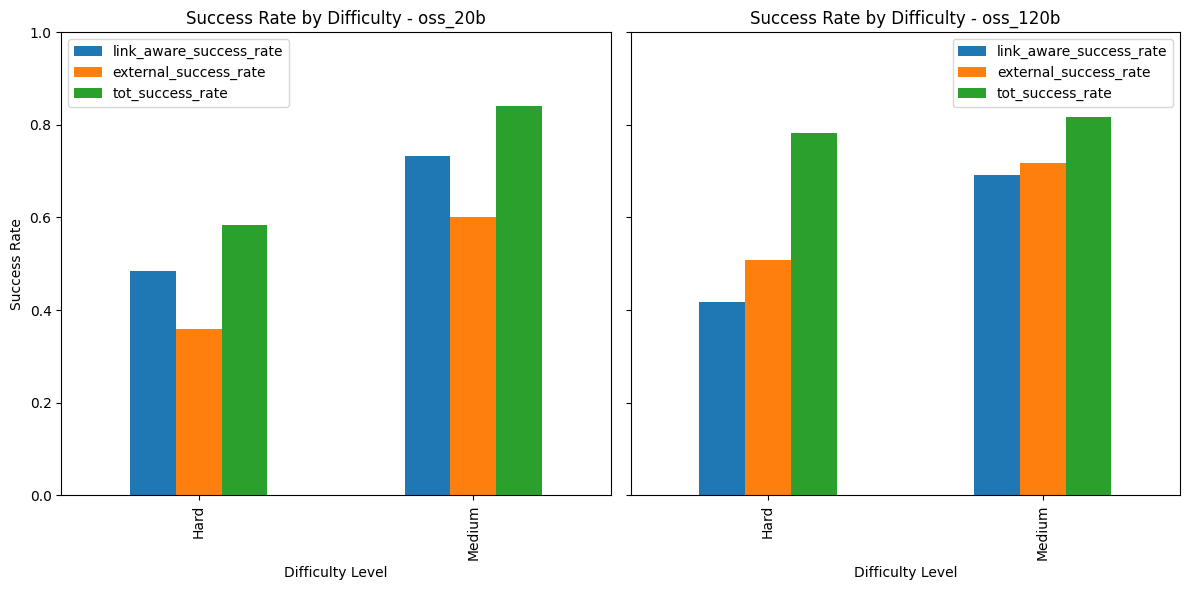

In [42]:
# python
models_order = ['oss_20b', 'oss_120b']

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for i, model in enumerate(models_order):
    ax = axes[i]
    group = llm_summary[llm_summary['model'] == model]
    if group.empty:
        ax.axis('off')
        continue
    group.plot(
        x='difficulty',
        y=['link_aware_success_rate', 'external_success_rate', 'tot_success_rate'],
        kind='bar',
        ax=ax,
        title=f'Success Rate by Difficulty - {model}',
        ylabel='Success Rate',
        xlabel='Difficulty Level',
        ylim=(0, 1),
        legend=True
    )

plt.tight_layout()
plt.show()

In [108]:
#we can also find the human success rate from precomputed results
agg_df = resolved_df.groupby(["start", "destination"]).agg(
            success_count=("end", lambda x: x.notnull().sum()),
            sample_count=("end", "size"),
            path_length=("path", lambda x: x.dropna().map(len).mean())
).reset_index()

# success rate
agg_df["success_rate"] = agg_df["success_count"] / agg_df["sample_count"]
#select all the  pairs in my llm_path_stats
human_success_rates = []
for idx, row in llm_path_stats.iterrows():
    start = row['start']
    destination = row['destination']
    match = agg_df[(agg_df['start'] == start) & (agg_df['destination'] == destination)]
    if not match.empty:
        human_success_rates.append(match['success_rate'].values[0])
    else:
        human_success_rates.append(None)
llm_path_stats['human_success_rate'] = human_success_rates
llm_path_stats

,id,start,destination,blind_paths,blind_input_tokens,blind_output_tokens,link_aware_paths,link_aware_input_tokens,link_aware_output_tokens,external_info_paths,...,link_aware_success,external_success,tot_success,link_aware_time,external_time,tot_time,human_success_rate,link_aware_steps,external_steps,tot_steps
0,Brain_Telephone_0,Brain,Telephone,"[""Brain"", ""Cognitive science"", ""Communication""...",298,444,"[""Brain"", ""Computer_science"", ""Internet""]",3036,3312,"[""Brain"", ""Action\u00a0potential""]",...,False,False,True,6348,2449,10739,0.508806,NaN,NaN,4.0
1,Theatre_Zebra_0,Theatre,Zebra,"[""Theatre"", ""Performing arts"", ""Circus"", ""Circ...",300,1276,"[""Theatre"", ""France"", ""Kenya"", ""East_Africa"", ...",5196,2950,"[""Theatre"", ""Dance"", ""Animal"", ""Mammal"", ""Zebra""]",...,True,True,True,8146,8122,34993,0.509285,7.0,5.0,6.0
2,Asteroid_Viking_0,Asteroid,Viking,"[""Asteroid"", ""Ceres (dwarf planet)"", ""Dwarf pl...",300,1711,"[""Asteroid"", ""Mars"", ""Mars_Reconnaissance_Orbi...",1986,2631,"[""Asteroid"", ""Mars""]",...,False,False,False,4617,12298,0,0.589266,NaN,NaN,NaN
3,Batman_Wood_0,Batman,Wood,NaN,0,0,"[""Batman"", ""Scotland""]",5584,5656,"[""Batman"", ""Crime""]",...,False,False,False,11240,10794,0,0.663677,NaN,NaN,NaN
4,Beer_Sun_0,Beer,Sun,"[""Beer"", ""Hops"", ""Humulus lupulus"", ""Plant"", ""...",298,1333,"[""Beer"", ""Ethanol"", ""Alcohol"", ""Hydrogen"", ""St...",3035,3174,"[""Beer"", ""Water"", ""Solar_System"", ""Sun""]",...,True,True,False,6209,6941,0,0.697183,6.0,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Napoleonic_Wars_Superman_5,Napoleonic_Wars,Superman,NaN,0,0,"[""Napoleonic_Wars"", ""United_States""]",4898,2386,"[""Napoleonic_Wars"", ""United_States""]",...,False,False,True,7284,9651,35218,0.357143,NaN,NaN,7.0
476,Batman_Wikisource_5,Batman,Wikisource,"[""Batman"", ""Copyright"", ""Public domain"", ""Wiki...",300,1067,"[""Batman"", ""Superman"", ""World_War_I""]",7025,4117,"[""Batman"", ""Chemistry""]",...,False,False,True,11142,19777,260208,0.307692,NaN,NaN,11.0
477,Christianity_Coconut_crab_5,Christianity,Coconut_crab,"[""Christianity"", ""Christianity and animals"", ""...",302,647,"[""Christianity"", ""Oceania""]",6103,3179,"[""Christianity"", ""Philippines""]",...,False,False,True,9282,16022,3991,0.307692,NaN,NaN,4.0
478,David_Beckham_Frog_5,David_Beckham,Frog,"[""David_Beckham"", ""England"", ""United_Kingdom"",...",303,1238,"[""David_Beckham"", ""England"", ""Lake_District"", ...",5278,2860,"[""David_Beckham"", ""Israel""]",...,True,False,True,8138,19409,23807,0.384615,10.0,NaN,10.0


In [109]:
agg_df

,start,destination,success_count,sample_count,path_length,success_rate
0,10th_century,11th_century,3,3,2.0,1.0
1,10th_century,Banknote,1,1,5.0,1.0
2,10th_century,Country,1,1,3.0,1.0
3,10th_century,Harlem_Globetrotters,2,2,4.5,1.0
4,10th_century,History_of_democracy,1,1,6.0,1.0
...,...,...,...,...,...,...
42707,Zürich,Mediterranean_Sea,1,1,4.0,1.0
42708,Zürich,Polar_ice_cap,0,1,10.0,0.0
42709,Zürich,Vegetation,0,1,3.0,0.0
42710,Zürich,Water_polo,0,1,4.0,0.0


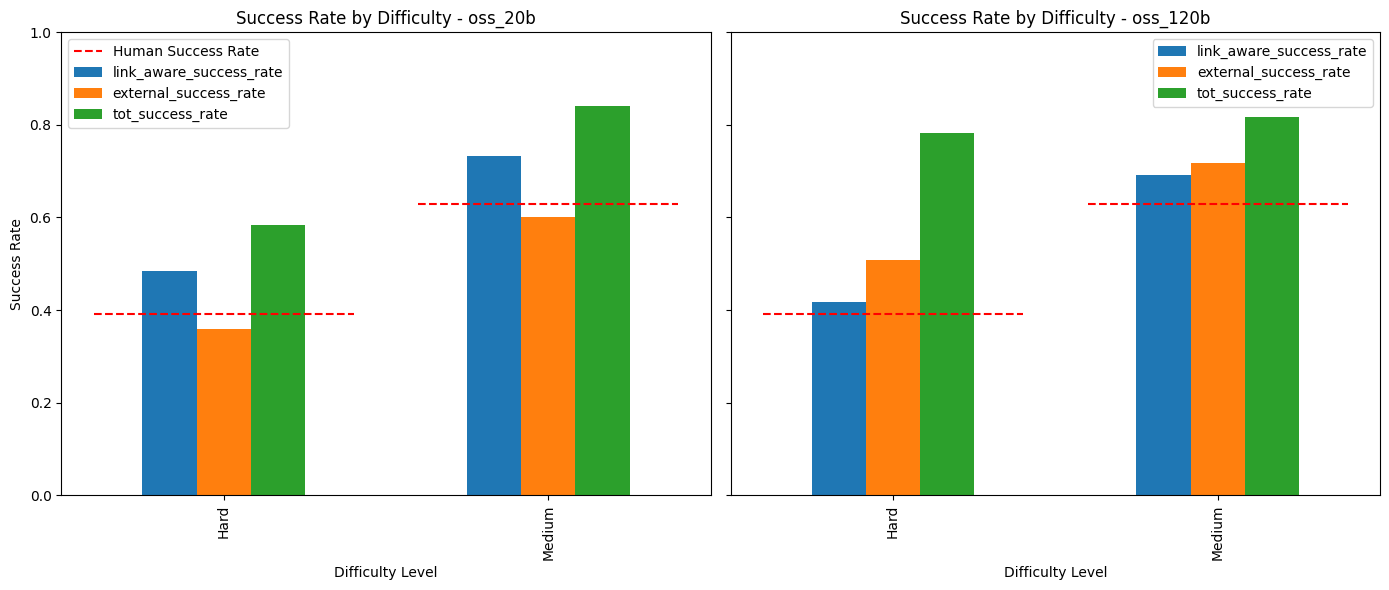

In [93]:
# python
import numpy as np
import matplotlib.pyplot as plt

llm_summary = llm_path_stats.groupby(['model', 'difficulty']).agg(
    link_aware_success_rate=('link_aware_success', 'mean'),
    external_success_rate=('external_success', 'mean'),
    tot_success_rate=('tot_success', 'mean'),
    count=('link_aware_success', 'size')
).reset_index()

human_success_summary = llm_path_stats.groupby(['model', 'difficulty']).agg(
    human_success_rate_avg=('human_success_rate', 'mean')
).reset_index()


llm_summary = pd.merge(llm_summary, human_success_summary, on=['model', 'difficulty'], how='left')


models_order = ['oss_20b', 'oss_120b']


all_difficulties = sorted(llm_summary['difficulty'].dropna().unique().tolist(), key=lambda x: (str(x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

#human success rate not a bar, but a horizontal line for each difficulty level for each model
for i, model in enumerate(models_order):
    ax = axes[i]
    group = llm_summary[llm_summary['model'] == model]
    if group.empty:
        ax.axis('off')
        continue
    group.plot(
        x='difficulty',
        y=['link_aware_success_rate', 'external_success_rate', 'tot_success_rate'],
        kind='bar',
        ax=ax,
        title=f'Success Rate by Difficulty - {model}',
        ylabel='Success Rate',
        xlabel='Difficulty Level',
        ylim=(0, 1),
        legend=True
    )
    for _, row in group.iterrows():
        difficulty = row['difficulty']
        human_rate = row['human_success_rate_avg']
        if pd.notna(human_rate):
            ax.hlines(y=human_rate, xmin=all_difficulties.index(difficulty) - 0.4, xmax=all_difficulties.index(difficulty) + 0.4, colors='red', linestyles='dashed', label='Human Success Rate' if difficulty == all_difficulties[0] else "")
    if i == 0:
        ax.legend()
plt.tight_layout()
plt.show()



In [44]:
#time usage analysis by model, difficulty and method, time is defined by sum of input tokens and output tokens
llm_path_stats['link_aware_time'] = llm_path_stats['link_aware_input_tokens'] + llm_path_stats['link_aware_output_tokens']
llm_path_stats['external_time'] = llm_path_stats['external_info_input_tokens'] + llm_path_stats['external_info_output_tokens']
llm_path_stats['tot_time'] = llm_path_stats['tot_input_tokens'] + llm_path_stats['tot_output_tokens']

In [46]:
llm_time_summary = llm_path_stats.groupby(['model', 'difficulty']).agg(
    link_aware_time_avg=('link_aware_time', 'mean'),
    external_time_avg=('external_time', 'mean'),
    tot_time_avg=('tot_time', 'mean'),
).reset_index()

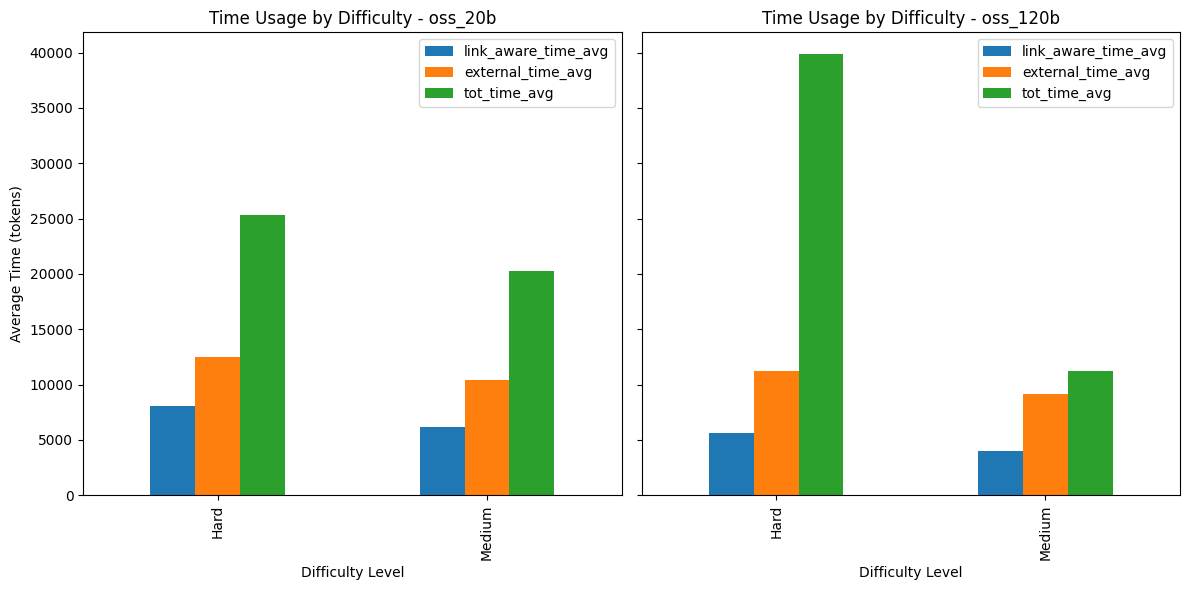

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for i, model in enumerate(models_order):
    ax = axes[i]
    group = llm_time_summary[llm_time_summary['model'] == model]
    if group.empty:
        ax.axis('off')
        continue
    group.plot(
        x='difficulty',
        y=['link_aware_time_avg', 'external_time_avg', 'tot_time_avg'],
        kind='bar',
        ax=ax,
        title=f'Time Usage by Difficulty - {model}',
        ylabel='Average Time (tokens)',
        xlabel='Difficulty Level',
        legend=True
    )
plt.tight_layout()
plt.show()

In [116]:
# python
import numpy as np

def compute_steps(row: pd.Series, path_col: str) -> float:
    try:
        return len(get_path_list_from_row(row, path_col)) if is_valid_path(row[path_col], row['destination']) else np.nan
    except Exception:
        return np.nan

llm_path_stats['link_aware_steps'] = llm_path_stats.apply(lambda r: compute_steps(r, 'link_aware_paths'), axis=1)
llm_path_stats['external_steps'] = llm_path_stats.apply(lambda r: compute_steps(r, 'external_info_paths'), axis=1)
llm_path_stats['tot_steps'] = llm_path_stats.apply(lambda r: compute_steps(r, 'tot_paths'), axis=1)


In [117]:
#we also find the human average steps from precomputed results
avg_steps_list = []
for idx, row in llm_path_stats.iterrows():
    start = row['start']
    destination = row['destination']
    match = agg_df[(agg_df['start'] == start) & (agg_df['destination'] == destination)]
    if not match.empty:
        avg_steps_list.append(match['path_length'].values[0])
    else:
        avg_steps_list.append(None)
llm_path_stats['human_avg_steps'] = avg_steps_list
llm_path_stats

,id,start,destination,blind_paths,blind_input_tokens,blind_output_tokens,link_aware_paths,link_aware_input_tokens,link_aware_output_tokens,external_info_paths,...,external_success,tot_success,link_aware_time,external_time,tot_time,human_success_rate,link_aware_steps,external_steps,tot_steps,human_avg_steps
0,Brain_Telephone_0,Brain,Telephone,"[""Brain"", ""Cognitive science"", ""Communication""...",298,444,"[""Brain"", ""Computer_science"", ""Internet""]",3036,3312,"[""Brain"", ""Action\u00a0potential""]",...,False,True,6348,2449,10739,0.508806,NaN,NaN,4.0,4.962329
1,Theatre_Zebra_0,Theatre,Zebra,"[""Theatre"", ""Performing arts"", ""Circus"", ""Circ...",300,1276,"[""Theatre"", ""France"", ""Kenya"", ""East_Africa"", ...",5196,2950,"[""Theatre"", ""Dance"", ""Animal"", ""Mammal"", ""Zebra""]",...,True,True,8146,8122,34993,0.509285,7.0,5.0,6.0,5.660101
2,Asteroid_Viking_0,Asteroid,Viking,"[""Asteroid"", ""Ceres (dwarf planet)"", ""Dwarf pl...",300,1711,"[""Asteroid"", ""Mars"", ""Mars_Reconnaissance_Orbi...",1986,2631,"[""Asteroid"", ""Mars""]",...,False,False,4617,12298,0,0.589266,NaN,NaN,NaN,5.839548
3,Batman_Wood_0,Batman,Wood,NaN,0,0,"[""Batman"", ""Scotland""]",5584,5656,"[""Batman"", ""Crime""]",...,False,False,11240,10794,0,0.663677,NaN,NaN,NaN,5.609865
4,Beer_Sun_0,Beer,Sun,"[""Beer"", ""Hops"", ""Humulus lupulus"", ""Plant"", ""...",298,1333,"[""Beer"", ""Ethanol"", ""Alcohol"", ""Hydrogen"", ""St...",3035,3174,"[""Beer"", ""Water"", ""Solar_System"", ""Sun""]",...,True,False,6209,6941,0,0.697183,6.0,4.0,NaN,4.394366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Napoleonic_Wars_Superman_5,Napoleonic_Wars,Superman,NaN,0,0,"[""Napoleonic_Wars"", ""United_States""]",4898,2386,"[""Napoleonic_Wars"", ""United_States""]",...,False,True,7284,9651,35218,0.357143,NaN,NaN,7.0,5.071429
476,Batman_Wikisource_5,Batman,Wikisource,"[""Batman"", ""Copyright"", ""Public domain"", ""Wiki...",300,1067,"[""Batman"", ""Superman"", ""World_War_I""]",7025,4117,"[""Batman"", ""Chemistry""]",...,False,True,11142,19777,260208,0.307692,NaN,NaN,11.0,6.000000
477,Christianity_Coconut_crab_5,Christianity,Coconut_crab,"[""Christianity"", ""Christianity and animals"", ""...",302,647,"[""Christianity"", ""Oceania""]",6103,3179,"[""Christianity"", ""Philippines""]",...,False,True,9282,16022,3991,0.307692,NaN,NaN,4.0,4.076923
478,David_Beckham_Frog_5,David_Beckham,Frog,"[""David_Beckham"", ""England"", ""United_Kingdom"",...",303,1238,"[""David_Beckham"", ""England"", ""Lake_District"", ...",5278,2860,"[""David_Beckham"", ""Israel""]",...,False,True,8138,19409,23807,0.384615,10.0,NaN,10.0,6.461538


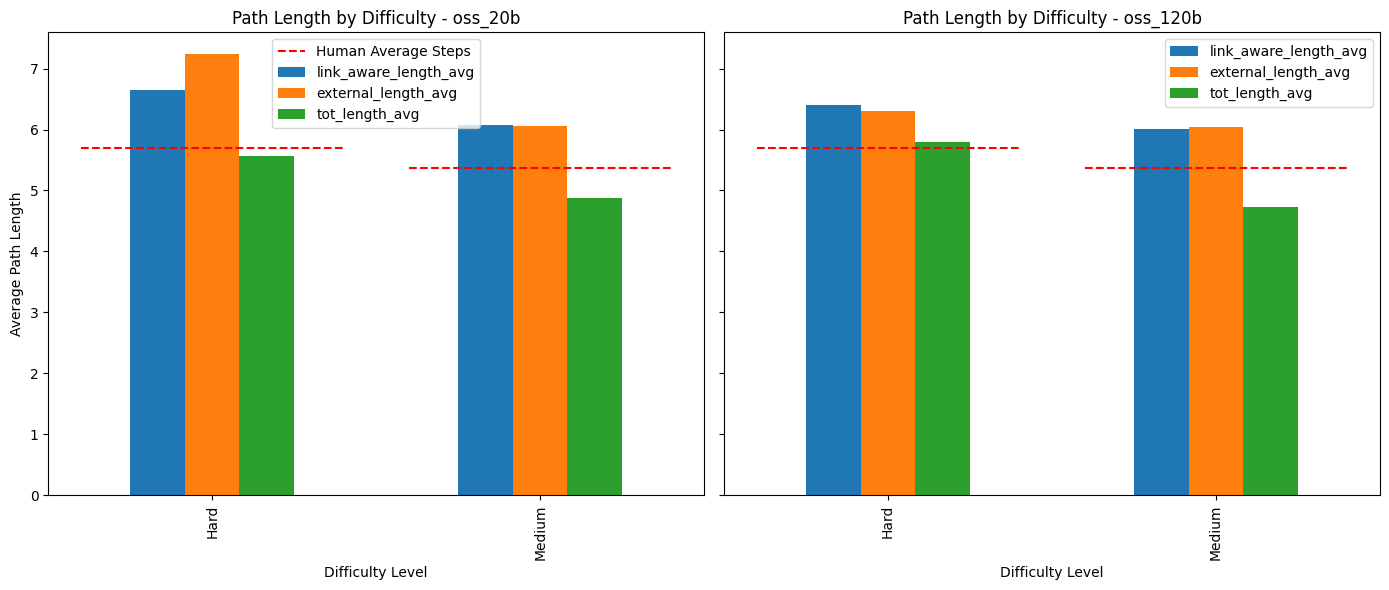

In [118]:
#visualize the length of paths taken by llm and human average steps, and again, human average steps is a horizontal dashed line
llm_length_summary = llm_path_stats.groupby(['model', 'difficulty']).agg(
    link_aware_length_avg=('link_aware_steps', 'mean'),
    external_length_avg=('external_steps', 'mean'),
    tot_length_avg=('tot_steps', 'mean'),
).reset_index()
human_length_summary = llm_path_stats.groupby(['model', 'difficulty']).agg(
    human_avg_steps_avg=('human_avg_steps',
    'mean')
).reset_index()
llm_length_summary = pd.merge(llm_length_summary, human_length_summary, on=['model', 'difficulty'], how='left')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for i, model in enumerate(models_order):
    ax = axes[i]
    group = llm_length_summary[llm_length_summary['model'] == model]
    if group.empty:
        ax.axis('off')
        continue
    group.plot(
        x='difficulty',
        y=['link_aware_length_avg', 'external_length_avg', 'tot_length_avg'],
        kind='bar',
        ax=ax,
        title=f'Path Length by Difficulty - {model}',
        ylabel='Average Path Length',
        xlabel='Difficulty Level',
        legend=True
    )
    for _, row in group.iterrows():
        difficulty = row['difficulty']
        human_length = row['human_avg_steps_avg']
        if pd.notna(human_length):
            ax.hlines(y=human_length, xmin=all_difficulties.index(difficulty) - 0.4, xmax=all_difficulties.index(difficulty) + 0.4, colors='red', linestyles='dashed', label='Human Average Steps' if difficulty == all_difficulties[0] else "")
    if i == 0:
        ax.legend()
plt.tight_layout()
plt.show()

In [48]:
# parsing auxiliary files into pd.DataFrame
articles = preprocessor.parse_input_file(config.input_file_articles)
categories = preprocessor.parse_input_file(config.input_file_categories)
links = preprocessor.parse_input_file(config.input_file_links)

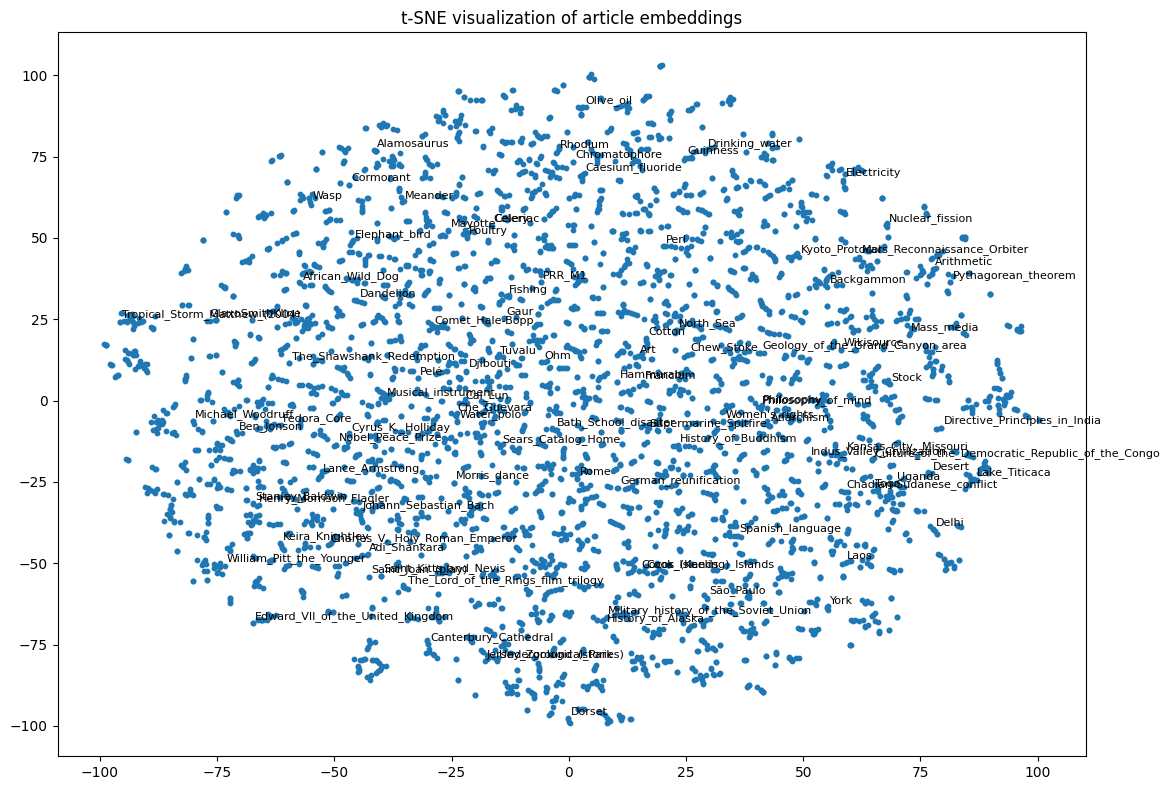

In [57]:
import torch
from sklearn.manifold import TSNE
import numpy as np

def visualize_semantic_space(metadata:pd.DataFrame, emb_path: str):
        #embeddings = torch.load(emb_path, weights_only=True)
    embeddings = torch.load(emb_path, map_location="cpu")
    articles_df = metadata
    embeddings_np = embeddings.detach().cpu().numpy()
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    embeddings_2d = tsne.fit_transform(embeddings_np)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=10, color='tab:blue')
    max_labels = 100
    indices_to_label = np.random.choice(len(metadata), size=min(max_labels, len(metadata)), replace=False)

    for i in indices_to_label:
        ax.text(
                embeddings_2d[i, 0] + 0.5,
                embeddings_2d[i, 1] + 0.5,
                s=metadata['article'].iloc[i],
                ha='left', va='bottom', fontsize=8
        )

    ax.set_title('t-SNE visualization of article embeddings')
    plt.tight_layout()
    plt.show()

visualize_semantic_space(metadata=articles,
    emb_path="results/article_emb/embeddings.pt")

In [120]:
#now modify the function, I wanna show a specific part of the semantic space, given a list of article titles

def visualize_specific_semantic_space(metadata:pd.DataFrame, emb_path: str, article_titles: list[str]):
        #embeddings = torch.load(emb_path, weights_only=True)
    embeddings = torch.load(emb_path, map_location="cpu")
    articles_df = metadata
    embeddings_np = embeddings.detach().cpu().numpy()
    tsne = TSNE(n_components=2, random_state=42, perplexity=5)
    embeddings_2d = tsne.fit_transform(embeddings_np)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=10, color='tab:blue')
    max_labels = 100
    indices_to_label = [i for i, title in enumerate(metadata['article']) if title in article_titles]
    for i in indices_to_label:
        ax.text(
                embeddings_2d[i, 0] + 0.5,
                embeddings_2d[i, 1] + 0.5,
                s=metadata['article'].iloc[i],
                ha='left', va='bottom', fontsize=8
        )
        ax.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], s=100, color='tab:red')
        #and link them with lines
        #the line didnt match the position, because
    for j in range(len(indices_to_label)-1):
        i1 = indices_to_label[j]
        i2 = indices_to_label[j+1]
        #linestyle is not dashed, but solid
        ax.plot([embeddings_2d[i1, 0], embeddings_2d[i2, 0]], [embeddings_2d[i1, 1], embeddings_2d[i2, 1]], color='tab:green', linewidth=5, linestyle='solid', alpha=0.5)
            
    #title show the path 
    ax.set_title('Path: ' + ' -> '.join(article_titles))
    plt.tight_layout()
    plt.show()


In [64]:
def get_path_list_from_row(row: pd.Series, path_column: str) -> list[str]:
    path_list = []
    cell = row[path_column]
    if pd.isna(cell):
        return path_list
    if isinstance(cell, (list, tuple)):
        return [str(item).strip() for item in cell]
    s = str(cell).strip()
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, (list, tuple)):
            return [str(item).strip() for item in parsed]
    except Exception:
        pass
    # 常见分隔符分割
    for sep in ['->', '|', ',', ';', '/']:
        if sep in s:
            return [str(item).strip() for item in s.split(sep)]
    return [s] if s != '' else path_list

get_path_list_from_row(llm_path_stats.iloc[0], 'link_aware_paths')

['Brain', 'Computer_science', 'Internet']

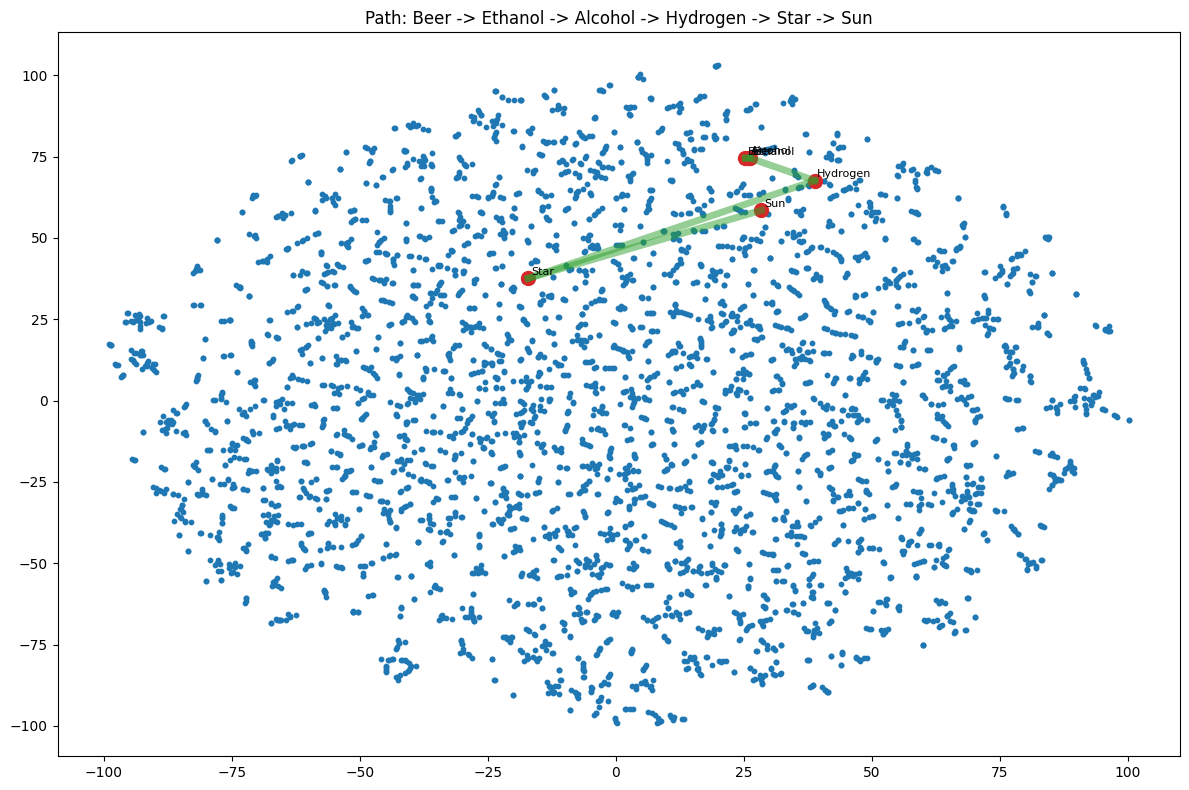

In [121]:
path_example = get_path_list_from_row(llm_path_stats.iloc[4], 'link_aware_paths')
visualize_specific_semantic_space(
    metadata=articles,
    emb_path="results/article_emb/embeddings.pt",
    article_titles=path_example
)  

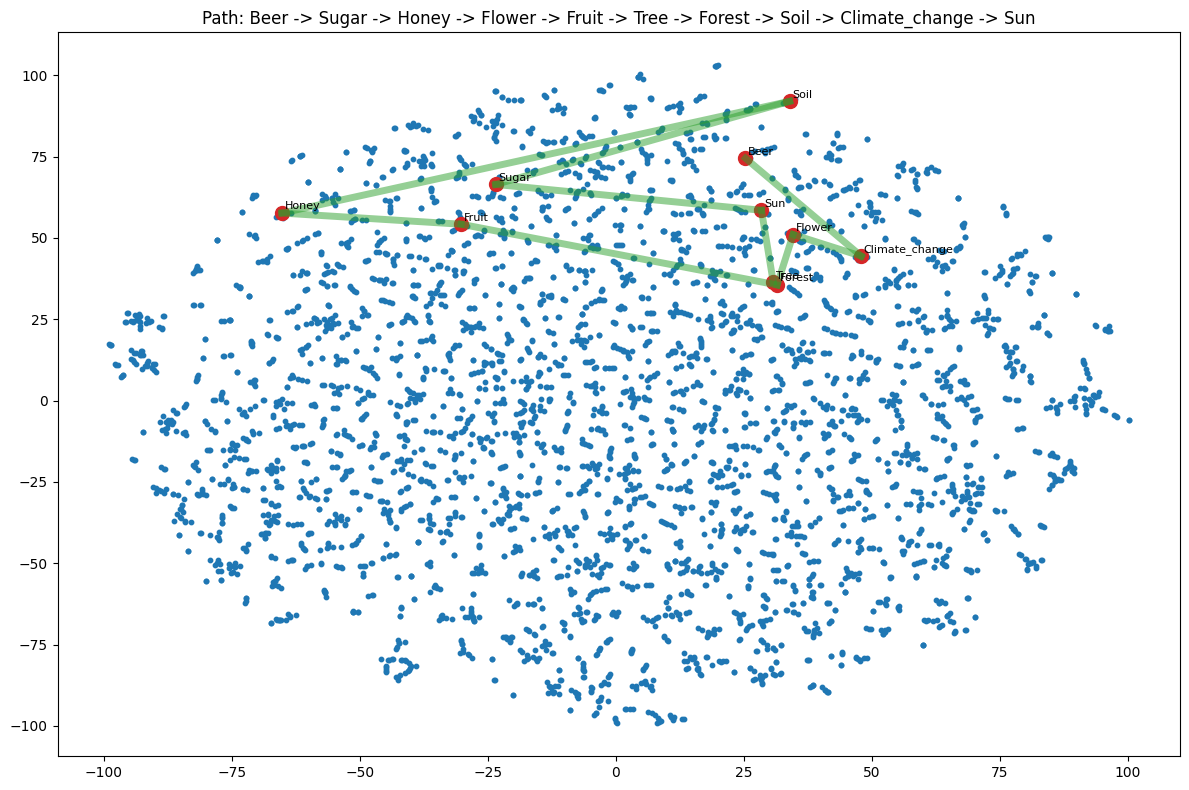

In [122]:
#find the corresponding human path for the same start and destination
start = llm_path_stats.iloc[4]['start']
destination = llm_path_stats.iloc[4]['destination']
human_paths = resolved_df[(resolved_df['start'] == start) & (resolved_df['destination'] == destination) & (resolved_df['end'].notnull())]['path'].tolist()
if human_paths:
    human_path = human_paths[0]  # take the first successful human path
    visualize_specific_semantic_space(
        metadata=articles,
        emb_path="results/article_emb/embeddings.pt",
        article_titles=human_path
    )